In [13]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

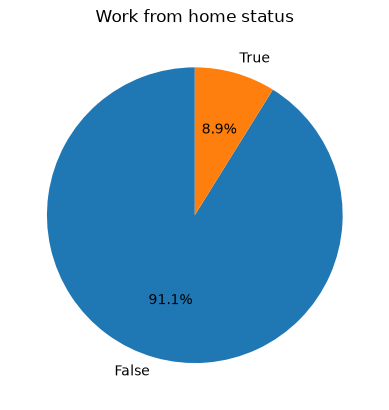

In [14]:
df['job_work_from_home'].value_counts().plot(kind ='pie', startangle = 90, autopct ='%1.1f%%')
plt.title('Work from home status')
plt.ylabel('')
plt.show()

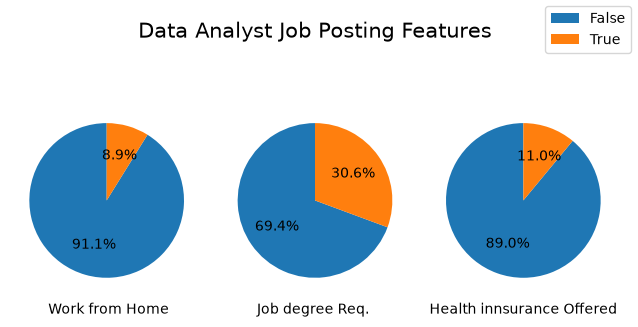

In [ ]:
fig, ax = plt.subplots(1,3)

df[['job_work_from_home', 'job_no_degree_mention', 'job_health_insurance']]
Titles = {'job_work_from_home': ' Work from Home' , 'job_no_degree_mention':'Job degree Req. ', 'job_health_insurance': 'Health innsurance Offered'}

for i, (column,title) in enumerate(Titles.items()):
    counts = df[column].value_counts()
    wedges,texts,autotexts = ax[i].pie(counts,startangle = 90, autopct = '%1.1f%%')
    ax[i].set_xlabel(title)      
fig.suptitle('Data Analyst Job Posting Features', fontsize = 15, y = 0.96)
fig.legend(wedges, counts.index)
fig.tight_layout(rect = [0, 0.30, 1, 0.95])#[left,bottom,right,top]
plt.show()